#Дз6

##Бганцова Полина, Б06-305

## **Часть 1. Анализ исходного качества (FastQC + MultiQC)**

### **Данные**:
- `Eg_Treg_S71_R1_001.fastq.gz` (19.8 млн ридов, 76 bp)
- `Eg_Treg_S71_R2_001.fastq.gz` (19.8 млн ридов, 76 bp)

### **Результаты:**


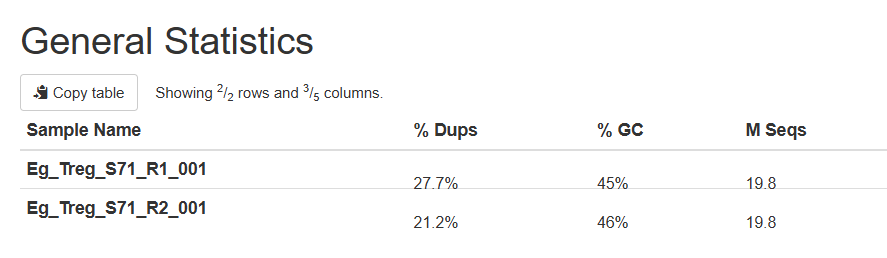

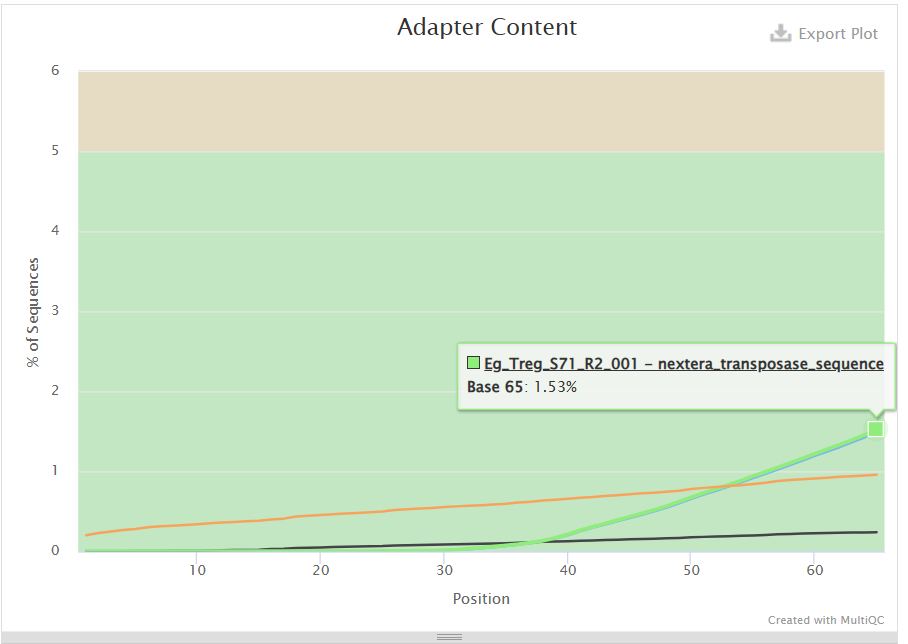

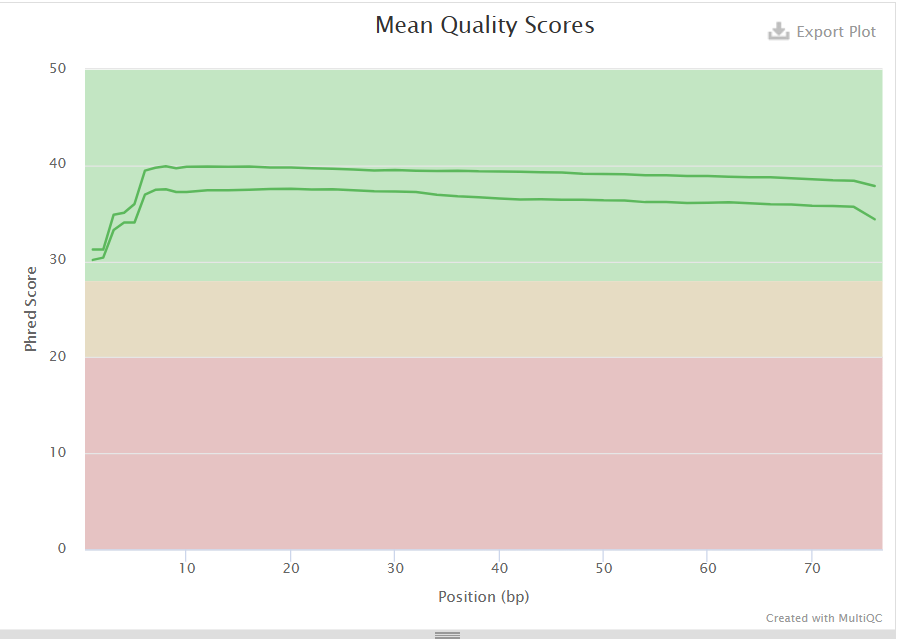

### **Выявленные проблемы:**

#### 1. Адаптеры
На графике Adapter Content обнаружены следующие адаптерные последовательности:

Адаптеры Nextera присутствуют в конце ридов в количестве 1.53% для обоих файлов.  
Поли-А последовательности обнаружены в незначительном количестве (0.24-0.96%), что может быть связано с естественными поли-А хвостами мРНК, а не с адаптерным загрязнением.


#### 2. Качество ридов
На графике Mean quality scores наблюдается постепенное снижение качества к 3'-концу рида.  
Однако на всём протяжении рида качество остаётся выше Q30.

Это означает, что даже на 3'-конце вероятность ошибки секвенирования составляет менее 0.1%.


#### 3. GC состав
Распределение GC content имеет один пик в области 45-46%, что соответствует транскриптому человека (ожидаемый диапазон 40-50%). Аномальных пиков не обнаружено.

#### 4. Дупликация (PCR duplicates)


Уровень дупликации составляет 21-28%, что находится в пределах нормы для RNA-seq (обычно 20-40%).  
Это указывает на отсутствие избыточной амплификации ПЦР при подготовке библиотеки.

###**Заключение:**  
Данные имеют хорошее качество (Q > 30, нормальный GC, умеренные дупликации).  
Единственная проблема — наличие адаптеров Nextera (1.53%), которые необходимо удалить перед выравниванием.

## **Часть 2. Тримминг с fastp и повторный QC**

### **Параметры тримминга:**

| Параметр | Значение | Назначение |
|----------|----------|------------|
| `--detect_adapter_for_pe` | автоматически | Поиск и удаление адаптеров в парных ридах |
| `--cut_window_size 4 --cut_mean_quality 20` | окно 4 bp, качество 20 | Обрезка по качеству скользящим окном |
| `--length_required 36` | 36 bp | Удаление ридов короче 36 bp |

### **Результаты:**

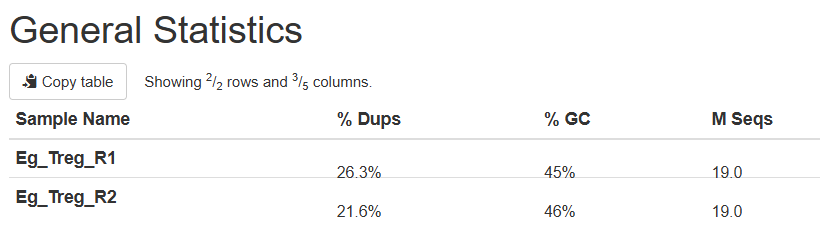

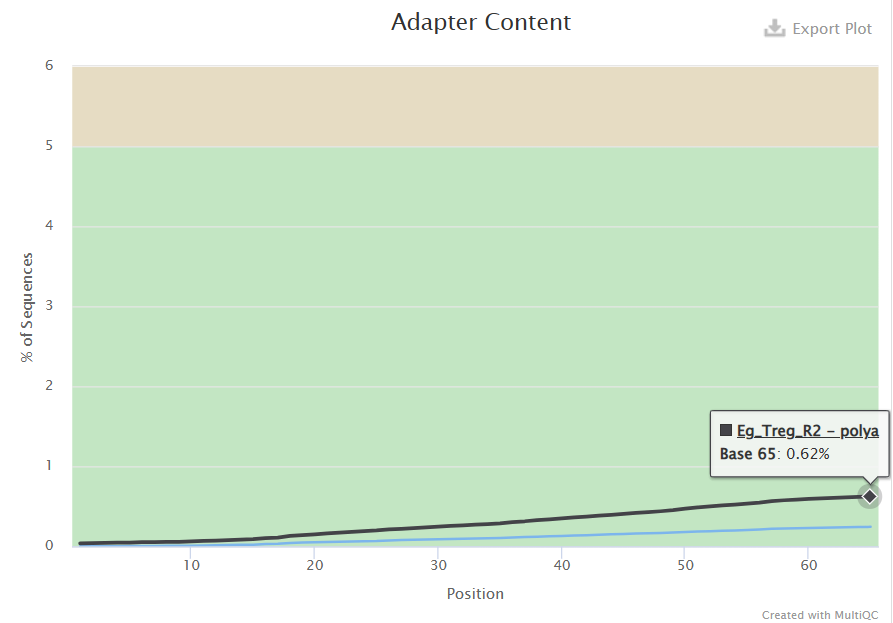

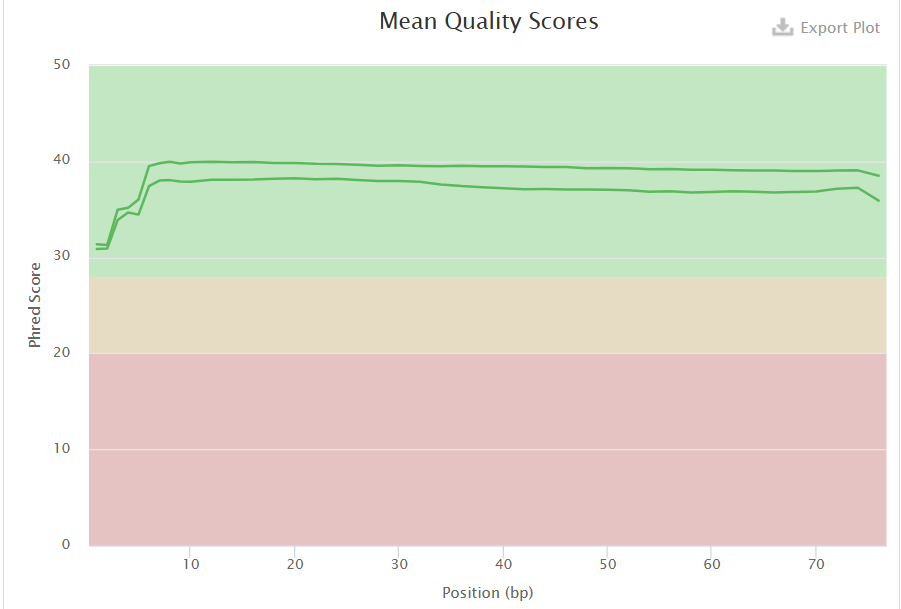

### **Анализ изменений:**

1. Адаптеры
- Nextera транспозазы: полностью исчезли в обоих файлах (<0.1%)
- Поли-А (R1): остался на уровне 0.24% (без изменений)
- Поли-А (R2): снизился с 0.96% до 0.62%

Поли-А последовательности являются естественной частью мРНК (поли-А хвост), а не адаптерным загрязнением. Тримминг удаляет только адаптеры, но не затрагивает биологически значимые поли-А хвосты, поэтому их уровень практически не изменился.

2. Качество ридов
- Практически не изменилось, улучшилось на ~1 единицу Q-score для обоих файлов

Исходное качество ридов уже было высоким (Q > 30 на всём протяжении). Тримминг обрезал только самые концевые участки с минимальным падением качества, поэтому общий Q30 вырос всего на ~1 единицу. Основной вклад в улучшение качества дало удаление адаптеров, а не обрезка по качеству.

3. Дупликация
- R1: снизилась с 27.7% до 26.3%
- R2: незначительно повысилась с 21.2% до 21.6%

Оба значения остаются в норме для RNA-seq (20-40%) и указывают на отсутствие проблем с ПЦР-амплификацией.


4. GC content — без значимых изменений.

5. Потеря данных
- С 19.8M до 19.0M ридов на файл
- Сохранено ~96% исходных данных


### **Для выравнивания выбираю триммированные данные**, так как:
- Адаптеры удалены → исключено ложное картирование
- Качество немного повысилось → точнее выравнивание
- Потеряно всего 4% → биологический сигнал сохранён

## **Часть 3. Выравнивание на референсный геном — STAR + StringTie**

### **3.1. STAR выравнивание**

**Параметры выравнивания:**
- Референсный геном: GRCh38
- Парные риды (триммированные)
- Режим: выравнивание с подсчётом генов (--quantMode GeneCounts)

**Скрипт STAR**

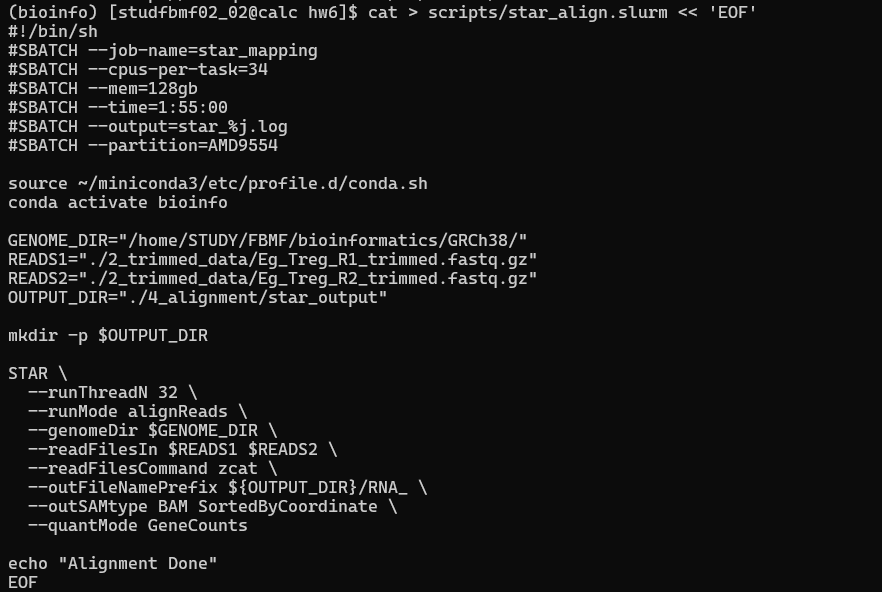

**Результаты STAR**

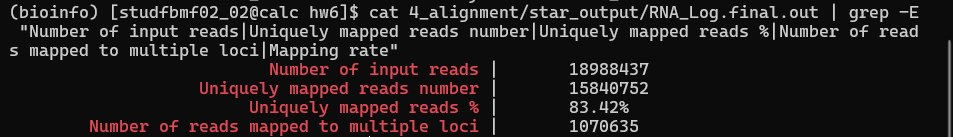

Выравнивание прошло успешно: 83.42% ридов картировались уникально, что является хорошим результатом для RNA-seq.

### **3.2. StringTie — сборка транскриптов de novo**

**Скрипт SrtingTie**

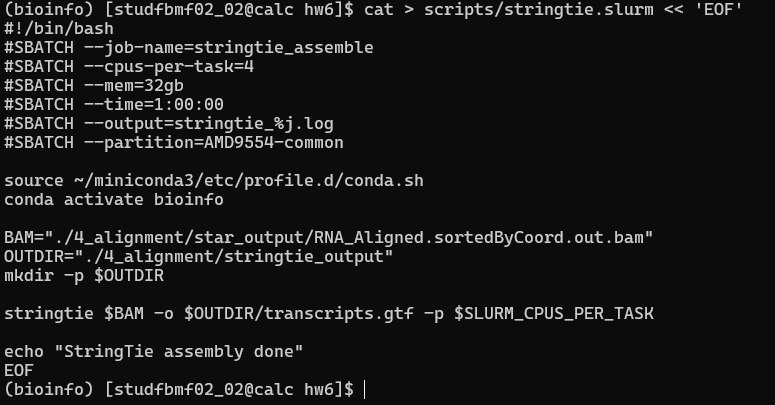

**Первые 10 строк transcripts.gtf и вывод количества транскриптов:**

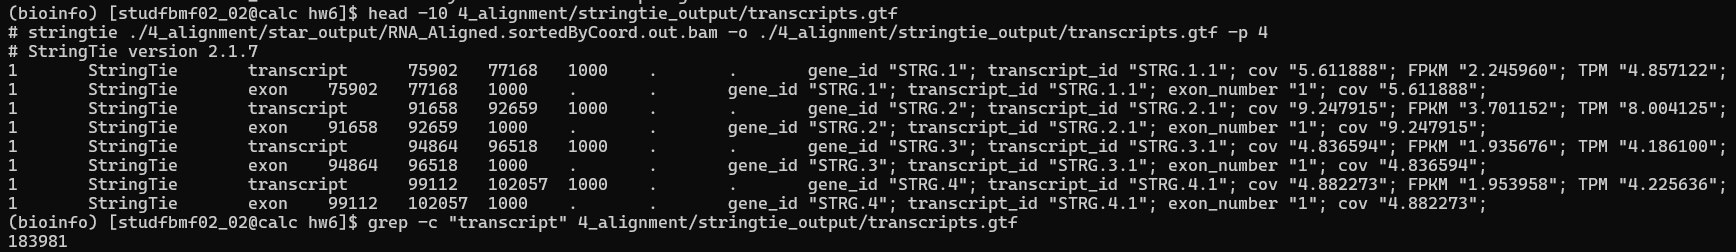

**Описание полей GTF (Gene Transfer Format):**

| № | Поле | Название | Описание |
|---|------|----------|----------|
| 1 | seqname | Хромосома | Идентификатор хромосомы или контига (1, 2, ...) |
| 2 | source | Источник | Программа, создавшая запись (StringTie) |
| 3 | feature | Тип объекта | transcript (транскрипт) или exon (экзон) |
| 4 | start | Старт | Начальная координата на хромосоме |
| 5 | end | Конец | Конечная координата на хромосоме |
| 6 | score | Доверие | Оценка достоверности (1000) |
| 7 | strand | Цепь | Направление транскрипции (+/-/.) |
| 8 | frame | Рамка | Рамка считывания (0,1,2 или . для некодирующих) |
| 9 | attributes | Атрибуты | Дополнительная информация: gene_id, transcript_id, cov (покрытие), FPKM, TPM |

**Количество транскриптов:** **183,981**

Это сопоставимо с референсной аннотацией GENCODE человека (~200,000 транскриптов), что указывает на успешную сборку транскриптома.

### **3.3. Для чего нужен transcripts.gtf**

Сборка транскриптов StringTie в режиме de novo позволяет:

1. **Обнаружить новые изоформы генов** — выявить альтернативные варианты сплайсинга, отсутствующие в референсной аннотации.

2. **Провести дифференциальную экспрессию на уровне транскриптов (DTU)** — с помощью инструментов DEXSeq, ballgown или IsoformSwitchAnalyzeR.

3. **Аннотировать новый геном** — при сборке de novo, когда нет готового GTF-файла.

4. **Сравнить с референсной аннотацией** — оценить полноту сборки и выявить потенциально новые транскрипты.

5. **Оценить экспрессию транскриптов** — файл содержит количественные метрики (cov, FPKM, TPM) для каждого транскрипта.

## **Часть 4. Подсчёт ридов на гены и сравнение с STAR**

### **4.1. Подсчёт ридов на гены**

Для подсчёта количества ридов, картированных на экзоны генов, использовалась программа **featureCounts** (пакет subread).

**Причина замены HTSeq на featureCounts:**  
При попытке запустить HTSeq возникли ошибки, связанные с отсутствием библиотеки libcrypto.so.1.0.0 и проблемами с PySam, я не смогла их уставновить:((

**Параметры подсчёта:**
- Тип подсчёта: exon
- Идентификатор гена: gene_id
- Режим: парные риды (-p)


**Скрипт**

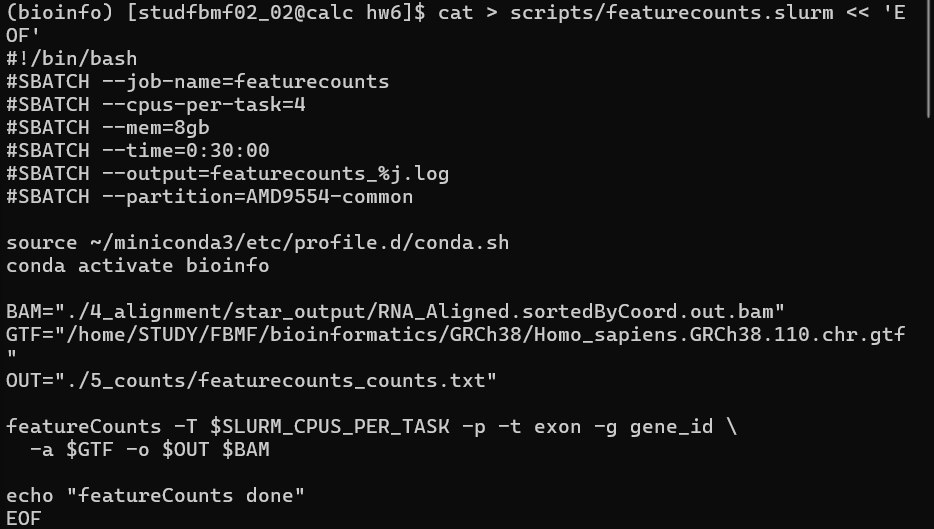

**Результат:**

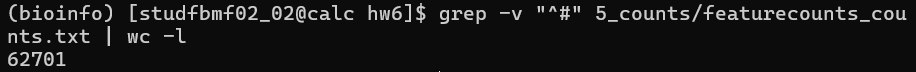

- **Количество уникальных генов:** **62,701**

### **4.2. Сравнение STAR vs featureCounts**

Для сравнения оценок экспрессии, полученных двумя методами (STAR — встроенный подсчёт, featureCounts — подсчёт по GTF), был построен scatter plot на логарифмической шкале.

Pearson correlation: 0.9399
Number of genes: 6604


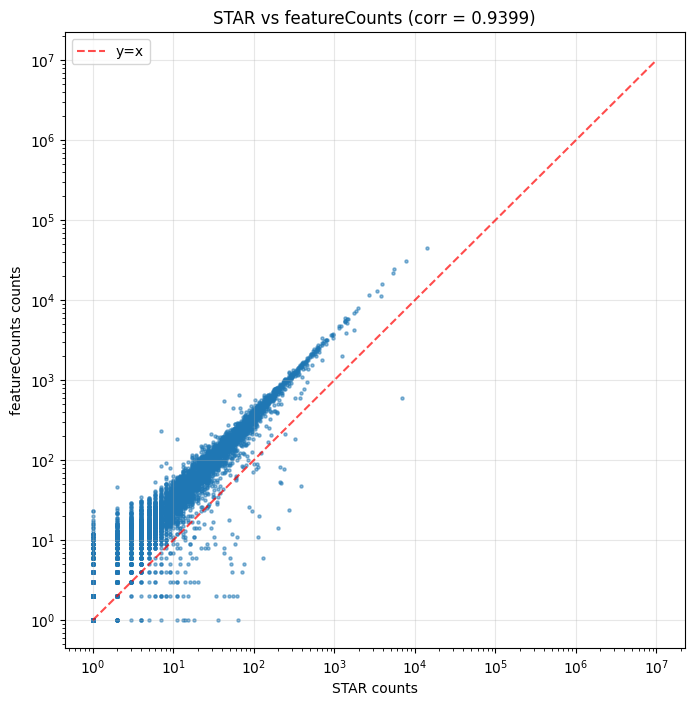


Пример сравнения (первые 10 генов):
            gene_id  star_counts  fc_counts
1   ENSG00000228037           19       83.0
2   ENSG00000142611            2        8.0
3   ENSG00000284616            4       11.0
4   ENSG00000157911           22       53.0
6   ENSG00000228463           31       83.0
9   ENSG00000226374            3        9.0
10  ENSG00000229280           12       55.0
11  ENSG00000142655           32       35.0
12  ENSG00000232596           32       92.0
14  ENSG00000231510            6       20.0


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Читаем STAR counts (колонка 3 - unstranded)
star = pd.read_csv("RNA_ReadsPerGene.out.tab", sep="\t", header=None, usecols=[0,2], names=["gene_id", "star_counts"])

# Убираем служебные строки (начинаются с N_)
star = star[~star["gene_id"].str.startswith("N_", na=False)]

# Преобразуем в числа
star["star_counts"] = pd.to_numeric(star["star_counts"], errors="coerce")

# Читаем featureCounts (последняя колонка)
fc = pd.read_csv("featurecounts_counts.txt", sep="\t", comment="#", header=None, usecols=[0,6], names=["gene_id", "fc_counts"])

# Преобразуем в числа
fc["fc_counts"] = pd.to_numeric(fc["fc_counts"], errors="coerce")

# Объединяем
df = pd.merge(star, fc, on="gene_id")

# Убираем нулевые и пропущенные значения
df = df.dropna()
df = df[(df["star_counts"] > 0) & (df["fc_counts"] > 0)]

# Корреляция
corr = df["star_counts"].corr(df["fc_counts"])
print(f"Pearson correlation: {corr:.4f}")
print(f"Number of genes: {len(df)}")

# График
plt.figure(figsize=(8, 8))
plt.scatter(df["star_counts"], df["fc_counts"], alpha=0.5, s=5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("STAR counts")
plt.ylabel("featureCounts counts")
plt.title(f"STAR vs featureCounts (corr = {corr:.4f})")
plt.plot([1, 1e7], [1, 1e7], 'r--', alpha=0.7, label="y=x")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("star_vs_featurecounts.png", dpi=150)
plt.show()

# Покажем примеры
print("\nПример сравнения (первые 10 генов):")
print(df.head(10))

**Результаты сравнения:**

| Показатель | Значение |
|------------|----------|
| Pearson корреляция | **0.9399** |
| Количество генов для сравнения | 6,604 |

### 4.3. Почему результаты не совпадают идеально?

**Корреляция 0.9399** указывает на сильную положительную связь между методами, однако наблюдаются расхождения.

| Причина | Объяснение |
|---------|------------|
| **Multi-mapping риды** | STAR учитывает риды, картированные в несколько мест (5.64% от всех), featureCounts по умолчанию их отбрасывает |
| **Перекрывающиеся гены** | featureCounts использует `union` режим — рид, попавший в перекрытие нескольких генов, не засчитывается |
| **Разная аннотация** | STAR использует аннотацию, встроенную в индекс при построении, featureCounts — внешний GTF |
| **Масштабирование** | featureCounts даёт систематически более высокие значения (см. пример: 19 vs 83), что указывает на разные алгоритмы подсчёта |

### 4.4. **Что лучше использовать для дальнейшего DE-анализа (DESeq2/edgeR)?**

**Рекомендуется featureCounts (или HTSeq-count)** по следующим причинам:

1. **Единая аннотация** — все образцы подсчитываются по одному GTF-файлу, что исключает вариабельность между образцами.

2. **Контроль режимов подсчёта** — можно выбрать стратегию обработки мульти-маппинг и перекрывающихся генов (union, intersection-strict, intersection-nonempty).

3. **Стандарт в биоинформатике** — featureCounts/HTSeq являются основой конвейеров DESeq2 и edgeR, что обеспечивает воспроизводимость результатов.

4. **Прозрачность** — все правила подсчёта задокументированы и не зависят от параметров выравнивателя (STAR).

**Вывод:** Для дифференциального экспрессионного анализа использую **featureCounts**, так как его результаты более стандартизированы и контролируемы, несмотря на более высокие абсолютные значения по сравнению со STAR.